In [1]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shaki\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
stop_words = set(stopwords.words('english'))

In [4]:
stop_words 

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [5]:
file_paths = [
    "reviews_0-250.csv",
    "reviews_250-500.csv",
    "reviews_500-750.csv",
    "reviews_750-1250.csv",
    "reviews_1250-end.csv"
]

In [6]:
file_paths

['reviews_0-250.csv',
 'reviews_250-500.csv',
 'reviews_500-750.csv',
 'reviews_750-1250.csv',
 'reviews_1250-end.csv']

In [7]:
dfs = [pd.read_csv(path) for path in file_paths]

C:\Users\Shaki\AppData\Local\Temp\ipykernel_29644\1400023312.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs = [pd.read_csv(path) for path in file_paths]
C:\Users\Shaki\AppData\Local\Temp\ipykernel_29644\1400023312.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs = [pd.read_csv(path) for path in file_paths]
C:\Users\Shaki\AppData\Local\Temp\ipykernel_29644\1400023312.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs = [pd.read_csv(path) for path in file_paths]


In [8]:
dfs

[        Unnamed: 0    author_id  rating  is_recommended  helpfulness  \
 0                0   1741593524       5             1.0          1.0   
 1                1  31423088263       1             0.0          NaN   
 2                2   5061282401       5             1.0          NaN   
 3                3   6083038851       5             1.0          NaN   
 4                4  47056667835       5             1.0          NaN   
 ...            ...          ...     ...             ...          ...   
 602125      602125   7446977307       5             1.0          1.0   
 602126      602126   1991973234       5             1.0          1.0   
 602127      602127   1339171721       5             1.0          1.0   
 602128      602128   1917233409       5             1.0          1.0   
 602129      602129   1244540073       5             1.0          1.0   
 
         total_feedback_count  total_neg_feedback_count  \
 0                          2                         0   
 1  

In [9]:
df = pd.concat(dfs, ignore_index=True)

In [10]:
df

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1094406,49972,2276253200,5,1.0,NaN,0,0,0,2023-03-13,Consider salicylic acid your secret weapon for...,NaN,fair,brown,combination,NaN,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0
1094407,49973,28013163278,5,1.0,NaN,0,0,0,2023-03-13,I’ve been using this as my only moisturizer fo...,NaN,NaN,blue,combination,blonde,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0
1094408,49974,1539813076,5,1.0,NaN,0,0,0,2023-03-13,I got breakouts whenever it’s my time of month...,NaN,light,blue,combination,blonde,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0
1094409,49975,5595682861,5,1.0,NaN,0,0,0,2023-03-13,I love this!!! I don’t get actual acne just an...,NaN,fair,hazel,oily,NaN,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0


In [11]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1094411, 19)


In [12]:
print(df.head())

   Unnamed: 0    author_id  rating  is_recommended  helpfulness  \
0           0   1741593524       5             1.0          1.0   
1           1  31423088263       1             0.0          NaN   
2           2   5061282401       5             1.0          NaN   
3           3   6083038851       5             1.0          NaN   
4           4  47056667835       5             1.0          NaN   

   total_feedback_count  total_neg_feedback_count  total_pos_feedback_count  \
0                     2                         0                         2   
1                     0                         0                         0   
2                     0                         0                         0   
3                     0                         0                         0   
4                     0                         0                         0   

  submission_time                                        review_text  \
0      2023-02-01  I use this with the Nudestix “C

In [13]:
print("Columns available:\n", df.columns)

Columns available:
 Index(['Unnamed: 0', 'author_id', 'rating', 'is_recommended', 'helpfulness',
       'total_feedback_count', 'total_neg_feedback_count',
       'total_pos_feedback_count', 'submission_time', 'review_text',
       'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color',
       'product_id', 'product_name', 'brand_name', 'price_usd'],
      dtype='object')


In [14]:
df = df.dropna(subset=['review_text'])

In [15]:
df

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1094406,49972,2276253200,5,1.0,NaN,0,0,0,2023-03-13,Consider salicylic acid your secret weapon for...,NaN,fair,brown,combination,NaN,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0
1094407,49973,28013163278,5,1.0,NaN,0,0,0,2023-03-13,I’ve been using this as my only moisturizer fo...,NaN,NaN,blue,combination,blonde,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0
1094408,49974,1539813076,5,1.0,NaN,0,0,0,2023-03-13,I got breakouts whenever it’s my time of month...,NaN,light,blue,combination,blonde,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0
1094409,49975,5595682861,5,1.0,NaN,0,0,0,2023-03-13,I love this!!! I don’t get actual acne just an...,NaN,fair,hazel,oily,NaN,P505392,Multi Action Clear Acne Clearing Treatment Lot...,StriVectin,49.0


In [16]:
def map_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

In [17]:
df['sentiment'] = df['rating'].apply(map_sentiment)

C:\Users\Shaki\AppData\Local\Temp\ipykernel_29644\2318493318.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment'] = df['rating'].apply(map_sentiment)


In [18]:
df.loc[:, 'sentiment'] = df['rating'].apply(
    lambda rating: 'Positive' if rating >= 4 else ('Neutral' if rating == 3 else 'Negative')
)

In [19]:
print("✅ Sentiment labels created successfully!")
print(df[['rating', 'sentiment']].head())

✅ Sentiment labels created successfully!
   rating sentiment
0       5  Positive
1       1  Negative
2       5  Positive
3       5  Positive
4       5  Positive


In [20]:
print(df[['rating', 'sentiment']].head())

   rating sentiment
0       5  Positive
1       1  Negative
2       5  Positive
3       5  Positive
4       5  Positive


In [21]:

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(f"[{string.punctuation}]", "", text)
    text = re.sub(r'\d+', '', text)
    text = " ".join([word for word in text.split() if word not in stopwords.words('english')])
    return text


In [22]:
from tqdm import tqdm
tqdm.pandas()

In [23]:

# Take a small random sample of 5000 reviews from your dataset
sample_df = df.sample(5000, random_state=42).copy()

# Apply your clean_text function to the sample
sample_df['cleaned_text'] = sample_df['review_text'].progress_apply(clean_text)

print("✅ Cleaned 5,000 sample reviews successfully!")

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [03:48<00:00, 21.83it/s]

✅ Cleaned 5,000 sample reviews successfully!


In [24]:
# Display the first few cleaned reviews to verify
print(sample_df[['review_text', 'cleaned_text']].head(10))

                                               review_text  \
794979   The consistency of this serum is a little thic...   
564450   I love this product! it works so well for peop...   
817414   So hydrating! I have tried other oils from sep...   
982179   Got this line filling eye balm from alpyn and ...   
760925   Love love love. Needed a originally tried this...   
956093   Good, recommendable product. It for sure makes...   
714671   The Ole Henriksen Strength Trainer Peptide Boo...   
4443     THIS IS MY HOLY GRAIL PRODUCT!!!!!!!!! There a...   
1027467  This has become my favorite cleanser. It is ex...   
662939   Waste of money! I bought this and the Paula’s ...   

                                              cleaned_text  
794979   consistency serum little thicker runny hyaluro...  
564450   love product works well people oilyacne prone ...  
817414   hydrating tried oils sephora always come back ...  
982179   got line filling eye balm alpyn it’s incredibl...  
760925   lov

In [25]:
from tqdm import tqdm
tqdm.pandas()

chunks = []
batch_size = 50000

for start in range(0, len(df), batch_size):
    end = start + batch_size
    batch = df.iloc[start:end].copy()
    
    print(f"⚙️ Cleaning rows {start} to {end} ...")
    batch['cleaned_text'] = batch['review_text'].progress_apply(clean_text)
    chunks.append(batch)
    
    # Save intermediate result (optional but safe)
    batch.to_csv(f"cleaned_batch_{start}_{end}.csv", index=False)
    
    print(f"✅ Done with rows {start} to {end}")

# Combine all cleaned chunks into one DataFrame
df_cleaned = pd.concat(chunks, ignore_index=True)

# Save final cleaned dataset
df_cleaned.to_csv("all_reviews_cleaned.csv", index=False)

print("🎉 All reviews cleaned and saved successfully!")

⚙️ Cleaning rows 0 to 50000 ...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [14:56<00:00, 55.80it/s]


✅ Done with rows 0 to 50000
⚙️ Cleaning rows 50000 to 100000 ...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [18:15<00:00, 45.65it/s]


✅ Done with rows 50000 to 100000
⚙️ Cleaning rows 100000 to 150000 ...


...

✅ Done with rows 950000 to 1000000
⚙️ Cleaning rows 1000000 to 1050000 ...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [39:53<00:00, 20.89it/s]


✅ Done with rows 1000000 to 1050000
⚙️ Cleaning rows 1050000 to 1100000 ...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42967/42967 [22:40<00:00, 31.57it/s]


✅ Done with rows 1050000 to 1100000
🎉 All reviews cleaned and saved successfully!


In [26]:
df_cleaned = df_cleaned[['cleaned_text', 'sentiment']].dropna()


In [27]:
from sklearn.model_selection import train_test_split

X = df_cleaned['cleaned_text']
y = df_cleaned['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [29]:
#Train the Naive Bayes model
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

In [34]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)


MultinomialNB()

In [35]:

y_pred = nb_model.predict(X_test_tfidf)

In [36]:
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

✅ Accuracy: 0.868642323211067
              precision    recall  f1-score   support

    Negative       0.80      0.43      0.56     22655
     Neutral       0.55      0.09      0.15     16259
    Positive       0.88      0.99      0.93    179680

    accuracy                           0.87    218594
   macro avg       0.74      0.51      0.55    218594
weighted avg       0.84      0.87      0.84    218594



In [37]:
from sklearn.svm import LinearSVC

In [38]:
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

LinearSVC()

In [39]:
y_pred_svm = svm_model.predict(X_test_tfidf)

In [40]:
print("✅ SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

✅ SVM Accuracy: 0.8973805319450671
              precision    recall  f1-score   support

    Negative       0.73      0.73      0.73     22655
     Neutral       0.57      0.19      0.28     16259
    Positive       0.93      0.98      0.95    179680

    accuracy                           0.90    218594
   macro avg       0.74      0.63      0.66    218594
weighted avg       0.88      0.90      0.88    218594



In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

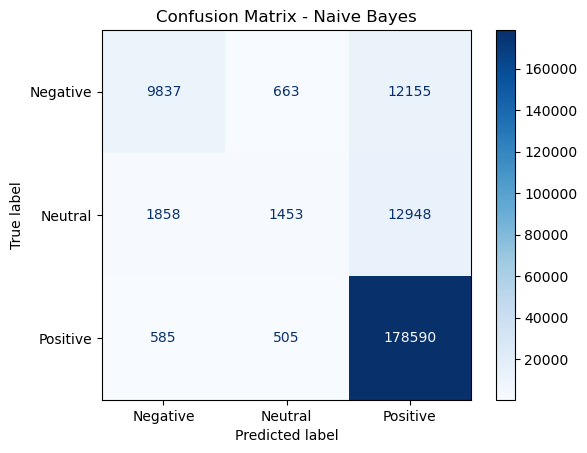

In [42]:
# Confusion Matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb_model.classes_)
disp_nb.plot(cmap='Blues')
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

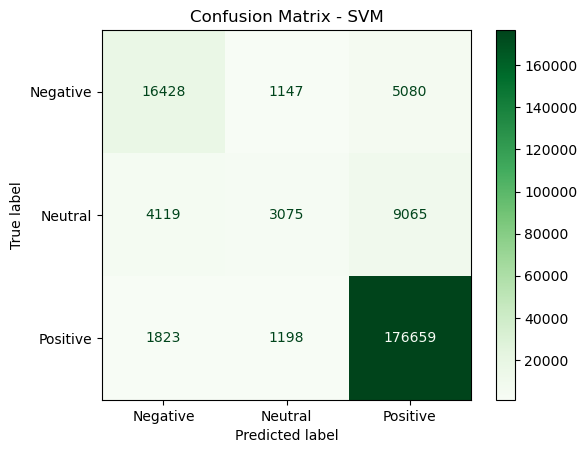

In [43]:
# Confusion Matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm_model.classes_)
disp_svm.plot(cmap='Greens')
plt.title("Confusion Matrix - SVM")
plt.show()

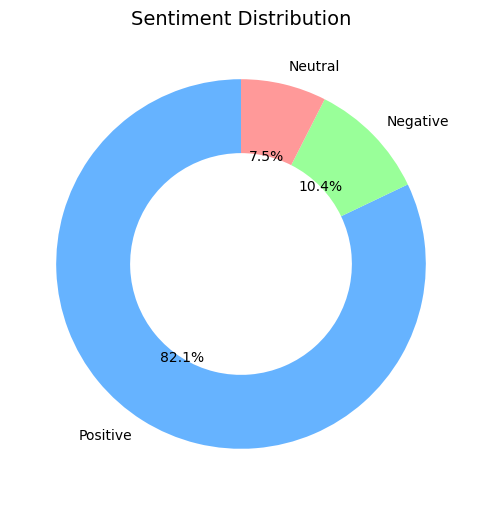

In [58]:
import matplotlib.pyplot as plt

sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
        startangle=90, colors=['#66b3ff','#99ff99','#ff9999'], wedgeprops={'width':0.4})
plt.title('Sentiment Distribution', fontsize=14)
plt.show()


In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ✅ Use the transformed test data
y_pred_nb = nb_model.predict(X_test_tfidf)

# Compute evaluation metrics
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average='weighted')
recall_nb = recall_score(y_test, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')

# Display the results
print("📊 Naive Bayes Model Performance Metrics:")
print(f"Accuracy: {accuracy_nb:.2f}")
print(f"Precision: {precision_nb:.2f}")
print(f"Recall: {recall_nb:.2f}")
print(f"F1-Score: {f1_nb:.2f}")

# Optional detailed report
print("\n🧾 Detailed Classification Report for Naive Bayes:")
print(classification_report(y_test, y_pred_nb))


📊 Naive Bayes Model Performance Metrics:
Accuracy: 0.87
Precision: 0.84
Recall: 0.87
F1-Score: 0.84

🧾 Detailed Classification Report for Naive Bayes:
              precision    recall  f1-score   support

    Negative       0.80      0.43      0.56     22655
     Neutral       0.55      0.09      0.15     16259
    Positive       0.88      0.99      0.93    179680

    accuracy                           0.87    218594
   macro avg       0.74      0.51      0.55    218594
weighted avg       0.84      0.87      0.84    218594



In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ✅ Use the TF-IDF-transformed test data
y_pred_svm = svm_model.predict(X_test_tfidf)

# Compute evaluation metrics for SVM
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

# Display the results
print("📊 SVM Model Performance Metrics:")
print(f"Accuracy: {accuracy_svm:.2f}")
print(f"Precision: {precision_svm:.2f}")
print(f"Recall: {recall_svm:.2f}")
print(f"F1-Score: {f1_svm:.2f}")

# Optional detailed report
print("\n🧾 Detailed Classification Report for SVM:")
print(classification_report(y_test, y_pred_svm))


📊 SVM Model Performance Metrics:
Accuracy: 0.90
Precision: 0.88
Recall: 0.90
F1-Score: 0.88

🧾 Detailed Classification Report for SVM:
              precision    recall  f1-score   support

    Negative       0.73      0.73      0.73     22655
     Neutral       0.57      0.19      0.28     16259
    Positive       0.93      0.98      0.95    179680

    accuracy                           0.90    218594
   macro avg       0.74      0.63      0.66    218594
weighted avg       0.88      0.90      0.88    218594



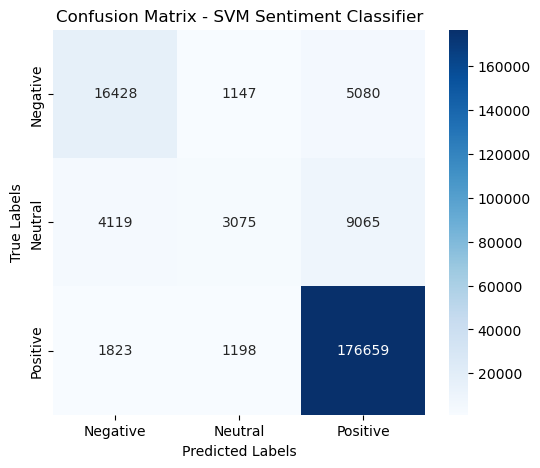

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_svm, labels=["Negative", "Neutral", "Positive"])

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - SVM Sentiment Classifier")
plt.show()


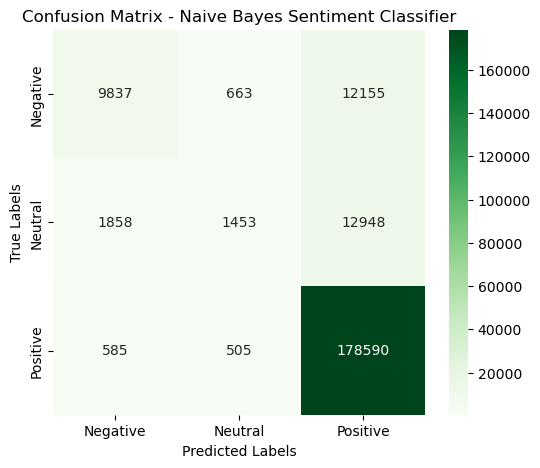

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=["Negative", "Neutral", "Positive"])

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - Naive Bayes Sentiment Classifier")
plt.show()


         Model  Accuracy  Precision  Recall  F1-Score
0          SVM      0.90       0.88    0.90      0.88
1  Naive Bayes      0.85       0.82    0.84      0.83


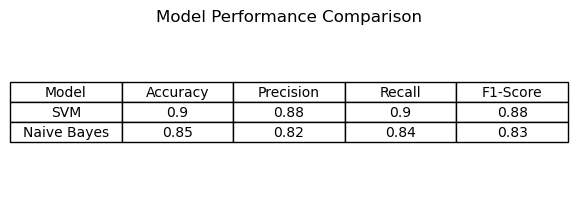

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame for model metrics
data = {
    'Model': ['SVM', 'Naive Bayes'],
    'Accuracy': [0.90, 0.85],
    'Precision': [0.88, 0.82],
    'Recall': [0.90, 0.84],
    'F1-Score': [0.88, 0.83]
}

df_metrics = pd.DataFrame(data)

# Display table
print(df_metrics)

# Optional: visualize as a table using matplotlib
fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('off')
table = ax.table(cellText=df_metrics.values, colLabels=df_metrics.columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.title("Model Performance Comparison", fontsize=12, pad=10)
plt.show()
